In [1]:
# UR3 CobotOps : UR3 협동로봇 운전 데이터 미니 프로젝트
# 읽기 -> 확인 -> EDA -> 전처리 -> 저장 -> ML

In [2]:
import pandas as pd

df = pd.read_excel('ur3_cobotops.xlsx')

# Timestamp 문자열 정리
df["Timestamp"] = (
    df["Timestamp"]
    .astype(str)
    .str.strip()       # 앞뒤 공백 제거
    .str.strip('"')    # 앞뒤 큰따옴표 제거
)

# 날짜/시간 타입으로 변환
df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    errors="coerce",
    utc=True
)

print("Timestamp 결측치:", df["Timestamp"].isnull().sum())

Timestamp 결측치: 0


In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
)

In [5]:
pd.set_option("display.max_columns", None) # 전체 컬럼 보기 옵션

In [6]:
# 1. 데이터 읽기
df = pd.read_excel("ur3_cobotops.xlsx", sheet_name="data")
df.columns = df.columns.str.strip()

print("데이터 크기:", df.shape)
df

데이터 크기: (7409, 24)


,Num,Timestamp,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,Current_J4,Temperature_J4,Current_J5,Temperature_J5,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,cycle,Robot_ProtectiveStop,grip_lost
0,1,2022-10-26T08:17:21.847Z,0.109628,27.8750,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,-0.062540,32.2500,-0.152622,32.0000,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,1,0.0,False
1,2,2022-10-26T08:17:22.852Z,0.595605,27.8750,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,-1.062762,32.2500,-0.260764,32.0000,-7.391485e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,1,0.0,False
2,3,2022-10-26T08:17:23.857Z,-0.229474,27.8750,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,-0.668869,32.3125,0.039071,32.0625,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,1,0.0,False
3,4,2022-10-26T08:17:24.863Z,0.065053,27.8750,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,-0.819755,32.2500,0.153903,32.0000,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,1,0.0,False
4,5,2022-10-26T08:17:25.877Z,0.884140,27.8750,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,-0.966427,32.3125,0.178998,32.0000,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,1,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7404,7405,2022-10-26T15:36:02.555Z,-0.109017,37.1875,-2.261695,40.3125,-1.082678,40.6875,-0.494714,43.3750,-0.019447,45.2500,0.023025,44.5625,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.080013,264,0.0,False
7405,7406,2022-10-26T15:36:03.562Z,-0.098536,37.1875,-2.251992,40.3125,-1.094420,40.6875,-0.515789,43.3750,-0.009186,45.2500,0.047794,44.5000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.078740,264,0.0,False
7406,7407,2022-10-26T15:36:04.571Z,-0.121100,37.1875,-2.280791,40.2500,-1.121319,40.6875,-0.502406,43.3750,-0.002978,45.2500,0.028567,44.5000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.091471,264,0.0,False
7407,7408,2022-10-26T15:36:05.572Z,-0.129370,37.1875,-2.269061,40.3125,-1.091610,40.6250,-0.491158,43.3750,-0.001136,45.2500,0.049641,44.5625,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.090026,264,0.0,False


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7409 entries, 0 to 7408
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Num                   7409 non-null   int64  
 1   Timestamp             7409 non-null   object 
 2   Current_J0            7363 non-null   float64
 3   Temperature_T0        7355 non-null   float64
 4   Current_J1            7355 non-null   float64
 5   Temperature_J1        7355 non-null   float64
 6   Current_J2            7355 non-null   float64
 7   Temperature_J2        7355 non-null   float64
 8   Current_J3            7355 non-null   float64
 9   Temperature_J3        7355 non-null   float64
 10  Current_J4            7355 non-null   float64
 11  Temperature_J4        7355 non-null   float64
 12  Current_J5            7355 non-null   float64
 13  Temperature_J5        7355 non-null   float64
 14  Speed_J0              7355 non-null   float64
 15  Speed_J1             

In [8]:
# 2. 데이터 품질 확인
print("\n결측치")
df.isnull().sum()


결측치


Num                      0
Timestamp                0
Current_J0              46
Temperature_T0          54
Current_J1              54
Temperature_J1          54
Current_J2              54
Temperature_J2          54
Current_J3              54
Temperature_J3          54
Current_J4              54
Temperature_J4          54
Current_J5              54
Temperature_J5          54
Speed_J0                54
Speed_J1                54
Speed_J2                54
Speed_J3                54
Speed_J4                54
Speed_J5                54
Tool_current            54
cycle                    0
Robot_ProtectiveStop    54
grip_lost                0
dtype: int64

In [9]:
# 3. Target 분포
print("\nProtective Stop 분포")
df["Robot_ProtectiveStop"].value_counts(dropna=False)


Protective Stop 분포


Robot_ProtectiveStop
0.0    7077
1.0     278
NaN      54
Name: count, dtype: int64

In [10]:
df["Robot_ProtectiveStop"].value_counts(normalize=True)
# df["Robot_ProtectiveStop"].value_counts(normalize=True).mul(100).round(1)

Robot_ProtectiveStop
0.0    0.962203
1.0    0.037797
Name: proportion, dtype: float64

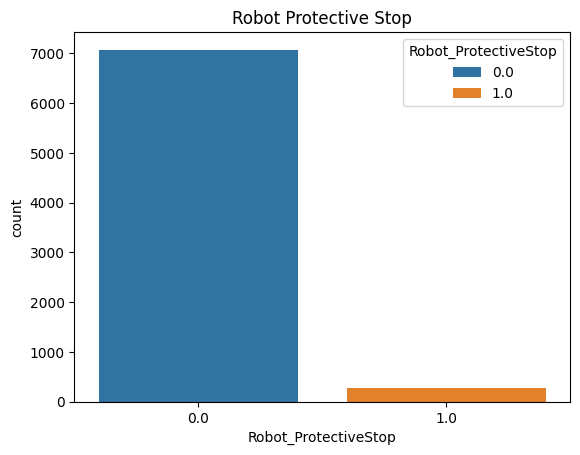

In [11]:
sns.countplot(data=df, x="Robot_ProtectiveStop", hue="Robot_ProtectiveStop")
plt.title("Robot Protective Stop")
plt.show()

In [12]:
# 4. 정상 / 정지 상태 센서 비교
compare_cols = [
    "Current_J0",
    "Current_J1",
    "Temperature_T0",
    "Temperature_J1",
    "Speed_J0",
    "Speed_J1",
    "Tool_current",
]

df.groupby("Robot_ProtectiveStop")[compare_cols].mean().round(3)

,Current_J0,Current_J1,Temperature_T0,Temperature_J1,Speed_J0,Speed_J1,Tool_current
Robot_ProtectiveStop,,,,,,,
0.0,-0.053,-2.281,34.875,37.622,0.002,-0.000,0.110
1.0,0.026,-2.737,35.725,38.618,-0.005,0.014,0.088


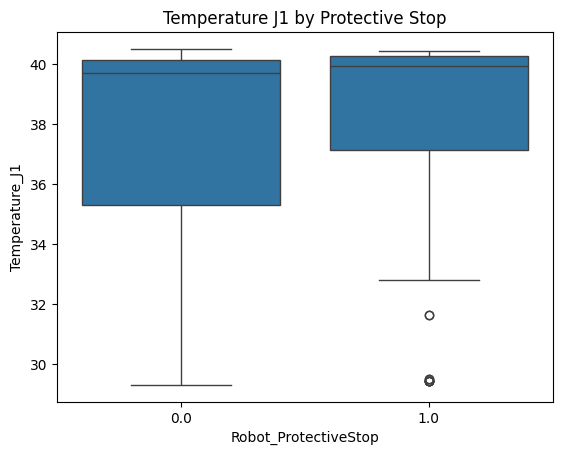

In [13]:
sns.boxplot(data=df, x="Robot_ProtectiveStop", y="Temperature_J1")
plt.title("Temperature J1 by Protective Stop")
plt.show()

In [14]:
# 5. 파생 변수

current_cols = [
    "Current_J0",
    "Current_J1",
    "Current_J2",
    "Current_J3",
    "Current_J4",
    "Current_J5",
]

temperature_cols = [
    "Temperature_T0",
    "Temperature_J1",
    "Temperature_J2",
    "Temperature_J3",
    "Temperature_J4",
    "Temperature_J5",
]

speed_cols = ["Speed_J0", "Speed_J1", "Speed_J2", "Speed_J3", "Speed_J4", "Speed_J5"]

df["avg_current"] = df[current_cols].mean(axis=1)
df["avg_temperature"] = df[temperature_cols].mean(axis=1)
df["avg_speed"] = df[speed_cols].mean(axis=1)

display(
    df.groupby("Robot_ProtectiveStop")[["avg_current", "avg_temperature", "avg_speed"]]
    .mean()
    .round(3)
)

,avg_current,avg_temperature,avg_speed
Robot_ProtectiveStop,,,
0.0,-0.690,39.307,0.000
1.0,-0.835,40.297,0.003


In [15]:
# 6. Timestamp 변환
# df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce") # <== 에러

# Timestamp 정리 및 날짜/시간 타입 변환, 불필요한 따옴표 제거
df["Timestamp"] = (
    df["Timestamp"]
    .astype(str)
    .str.strip()
    .str.strip('"')
)

df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    errors="coerce",
    utc=True
)

print("Timestamp 결측치:", df["Timestamp"].isnull().sum())
display(df[["Timestamp", "cycle", "Robot_ProtectiveStop"]])

Timestamp 결측치: 0


,Timestamp,cycle,Robot_ProtectiveStop
0,2022-10-26 08:17:21.847000+00:00,1,0.0
1,2022-10-26 08:17:22.852000+00:00,1,0.0
2,2022-10-26 08:17:23.857000+00:00,1,0.0
3,2022-10-26 08:17:24.863000+00:00,1,0.0
4,2022-10-26 08:17:25.877000+00:00,1,0.0
...,...,...,...
7404,2022-10-26 15:36:02.555000+00:00,264,0.0
7405,2022-10-26 15:36:03.562000+00:00,264,0.0
7406,2022-10-26 15:36:04.571000+00:00,264,0.0
7407,2022-10-26 15:36:05.572000+00:00,264,0.0


In [16]:
# 7. Target이 없는 행 제거
df_clean = df.dropna(subset=["Robot_ProtectiveStop"]).copy()
df_clean["Robot_ProtectiveStop"] = df_clean["Robot_ProtectiveStop"].astype(int)
print("원본 :", df.shape)
print("정리 :", df_clean.shape)
print("결측치 : ", "-" * 25 )
print(df_clean.isnull().sum())

원본 : (7409, 27)
정리 : (7355, 27)
결측치 :  -------------------------
Num                     0
Timestamp               0
Current_J0              0
Temperature_T0          0
Current_J1              0
Temperature_J1          0
Current_J2              0
Temperature_J2          0
Current_J3              0
Temperature_J3          0
Current_J4              0
Temperature_J4          0
Current_J5              0
Temperature_J5          0
Speed_J0                0
Speed_J1                0
Speed_J2                0
Speed_J3                0
Speed_J4                0
Speed_J5                0
Tool_current            0
cycle                   0
Robot_ProtectiveStop    0
grip_lost               0
avg_current             0
avg_temperature         0
avg_speed               0
dtype: int64


In [17]:
# 8. 전처리 데이터 저장
df_clean.to_csv("ur3_cobotops_prepared.csv", index=False, encoding="utf-8-sig")
print("저장 완료")

저장 완료


In [18]:
# 9. X / y 만들기
drop_cols = ["Num", "Timestamp", "cycle", "grip_lost", "Robot_ProtectiveStop"]
X = df_clean.drop(columns=drop_cols)
y = df_clean["Robot_ProtectiveStop"]
print("X:", X.shape)
print("y:", y.shape)
print(f"Protective Stop 비율: {y.mean():.1%}")

X: (7355, 22)
y: (7355,)
Protective Stop 비율: 3.8%


In [19]:
# 10. Train / Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (5884, 22)
Test : (1471, 22)


In [20]:
# 11. 결측치 처리
# Train의 중앙값을 Train/Test에 동일하게 사용
median = X_train.median()
X_train = X_train.fillna(median)
X_test = X_test.fillna(median)

In [21]:
# 12. Decision Tree
# 불균형 데이터이므로 class_weight="balanced"
model = DecisionTreeClassifier(
    max_depth=4, min_samples_split=20, class_weight="balanced", random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [22]:
# 13. 모델 평가
baseline = y_test.value_counts(normalize=True).max()
accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"정상만 예측할 때 Accuracy : {baseline:.2%}")
print(f"모델 Accuracy          : {accuracy:.2%}")
print(f"Balanced Accuracy     : {balanced_acc:.2%}")
print("\nClassification Report")
print(
    classification_report(
        y_test, y_pred, target_names=["Normal", "Protective Stop"], zero_division=0
    )
)

정상만 예측할 때 Accuracy : 96.19%
모델 Accuracy          : 73.28%
Balanced Accuracy     : 79.25%

Classification Report
                 precision    recall  f1-score   support

         Normal       0.99      0.73      0.84      1415
Protective Stop       0.11      0.86      0.20        56

       accuracy                           0.73      1471
      macro avg       0.55      0.79      0.52      1471
   weighted avg       0.96      0.73      0.82      1471



In [23]:
# 14. 혼동행렬
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm, index=["Actual Normal", "Actual Stop"], columns=["Pred Normal", "Pred Stop"]
)
cm_df

,Pred Normal,Pred Stop
Actual Normal,1030,385
Actual Stop,8,48


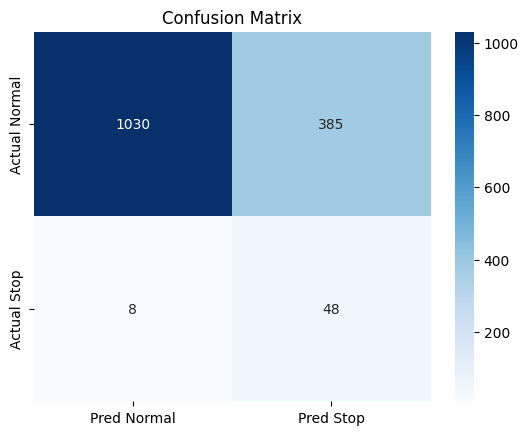

In [24]:
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [25]:
# 소수점 둘째 자리까지 표시 (원하는 자리수로 숫자를 변경하세요)
pd.options.display.float_format = '{:.2f}'.format

# 또는 아래 방식으로도 동일하게 작동합니다.
# pd.set_option('display.float_format', '{:.2f}'.format)

In [26]:
# 15. 변수 중요도
importance = pd.DataFrame(
    {"feature": X.columns, "importance": model.feature_importances_}
)
importance = importance.sort_values("importance", ascending=False)
importance.head(10)

,feature,importance
19,avg_current,0.41
15,Speed_J3,0.19
17,Speed_J5,0.14
18,Tool_current,0.10
10,Current_J5,0.07
5,Temperature_J2,0.07
6,Current_J3,0.03
12,Speed_J0,0.00
0,Current_J0,0.00
13,Speed_J1,0.00


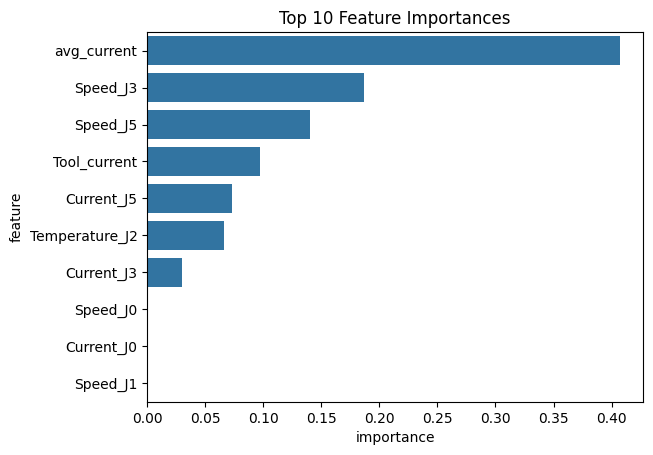

In [27]:
sns.barplot(data=importance.head(10), x="importance", y="feature")
plt.title("Top 10 Feature Importances")
plt.show()

In [28]:
# end